#  Netflix Movie Data Analysis using Python

##  Introduction

This project explores a Netflix movie dataset using Python to perform Exploratory Data Analysis (EDA). The objective is to clean the data, analyze movie trends, and extract meaningful insights through data visualization and statistical analysis.

##  Objective

The main objectives of this project are:

- Analyze the distribution of movie genres.
- Identify the most popular and highest-rated movies.
- Explore trends in movie releases over time.
- Understand the relationship between popularity, ratings, and audience votes.
- Generate meaningful business insights using Python and data visualization.

## Import Libraries

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [4]:
df = pd.read_csv('Netflixdb.csv', lineterminator = '\n')

In [5]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [7]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

## Data Cleaning & Preprocessing

In [8]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
# Generate summary statistics for all numerical columns
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [10]:
# Convert the 'Release_Date' column from object (string) to datetime format

df['Release_Date'] = pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtypes)

datetime64[ns]


In [11]:
# Extract the year from the 'Release_Date' column

df['Release_Date'] = df['Release_Date'].dt.year

df['Release_Date'].dtypes

dtype('int32')

In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
# Dropping the columns which is not useful

cols = ['Overview', 'Original_Language', 'Poster_Url']

In [14]:
df.drop(cols, axis = 1, inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [15]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


Categorizing Vote_Average Column

Categorize the 'Vote_Average' column into popular, average, below_avg, and not_popular 

In [16]:

# Define a function to categorize a numerical column into groups

def categorize_col(df, col, labels):
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

In [17]:
labels = [ 'not_popular', 'below_avg', 'average', 'popular'] 

categorize_col(df, 'Vote_Average', labels) 

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [18]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [19]:
# exploring column

df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [20]:
# dropping NaNs

df.dropna (inplace = True)

df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [21]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


# Separate multiple genres into individual rows for easier analysis.

In [22]:
# split the strings into Lists

df['Genre']= df['Genre'].str.split(', ')


In [23]:
#explode the Lists

df= df.explode('Genre').reset_index(drop=True)

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [24]:
# costing column into category

df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [26]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [27]:
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


# Exploratory Data Analysis (EDA) and Visualization (Q1–Q14)

In [28]:
# setting up seaborn configurations

sns.set_style('whitegrid')

## Q1: What is the most frequent genre in the dataset?

In [29]:
# showing stats. on genre column

df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

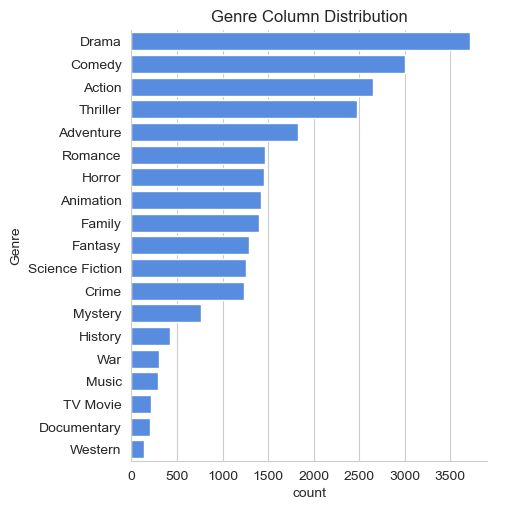

In [30]:
#visualizing genre column

sns.catplot(y = 'Genre', data = df, kind = 'count',

order = df['Genre'].value_counts().index,

color = '#4287f5')

plt.title('Genre Column Distribution')

plt.show()

###  Observation

- The dataset contains **19 unique movie genres**.
- **Drama** is the most frequent genre, appearing **3,715 times**.
- Out of **25,552** total genre entries, Drama contributes approximately **14.5%** of the dataset.
- This indicates that drama is the most commonly produced genre among the movies in the dataset.

## Q2: What genres has highest votes ?

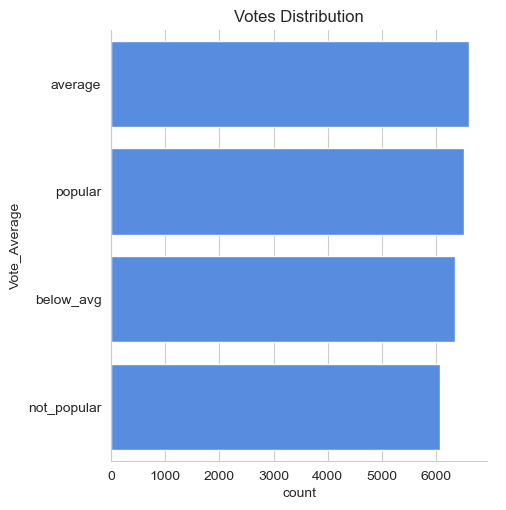

In [31]:
#visualizing Vote_Average column

sns.catplot(y = 'Vote_Average', data = df, kind = 'count',

            order = df[ 'Vote_Average'].value_counts().index,

            color = '#4287f5')

plt.title('Votes Distribution')

plt.show()

###  Observation

- The **Average** vote category contains the highest number of movies in the dataset.
- The **Popular** category is the second most common, indicating that many movies have received good audience ratings.
- The **Below Average** and **Not Popular** categories contain comparatively fewer movies.
- Overall, the distribution suggests that most movies in the dataset are rated between average and good by viewers.

## Q3: What movie got the highest popularity? what's its genre?

In [32]:
# checking max popularity in dataset

df [df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


###  Observation

- **Spider-Man: No Way Home (2021)** is the most popular movie in the dataset with a popularity score of **5083.954**.
- The movie belongs to **Action**, **Adventure**, and **Science Fiction** genres.
- It has received **8,940 votes**, indicating strong audience engagement.
- The high popularity score suggests that the movie attracted significant global attention.

## Q4: What movie got the lowest popularity? what's its genre?

In [33]:
# checking max popularity in dataset

df [df['Popularity']== df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


###  Observation

- Two movies share the **lowest popularity score** of **13.354** in the dataset.
- **The United States vs. Billie Holiday (2021)** belongs to the **Music**, **Drama**, and **History** genres.
- **Threads (1984)** belongs to the **War**, **Drama**, and **Science Fiction** genres.
- Since the dataset was exploded by genre, each movie appears multiple times, with one row representing each genre.

## Q5: Which year has the most filmmed movies?

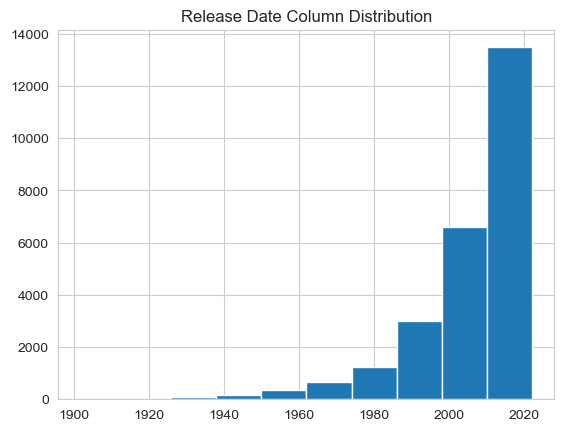

In [34]:
df['Release_Date'].hist()

plt.title('Release Date Column Distribution')

plt.show()

###  Observation

- The distribution of movie releases is heavily concentrated in recent years.
- Most movies in the dataset were released between **2010 and 2022**.
- The highest number of movie releases is observed in the **latest years**, indicating a significant increase in movie production over time.
- Very few movies in the dataset were released before the 1980s.

##  Q6. What are the Top 10 Most Popular Movies?

In [35]:
# Display the top 10 most popular movies based on the popularity score

top_10_popular = df.sort_values(by='Popularity', ascending=False)[['Title', 'Popularity']].head(10)

top_10_popular

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
2,Spider-Man: No Way Home,5083.954
1,Spider-Man: No Way Home,5083.954
3,The Batman,3827.658
5,The Batman,3827.658
4,The Batman,3827.658
6,No Exit,2618.087
9,Encanto,2402.201
10,Encanto,2402.201
7,Encanto,2402.201


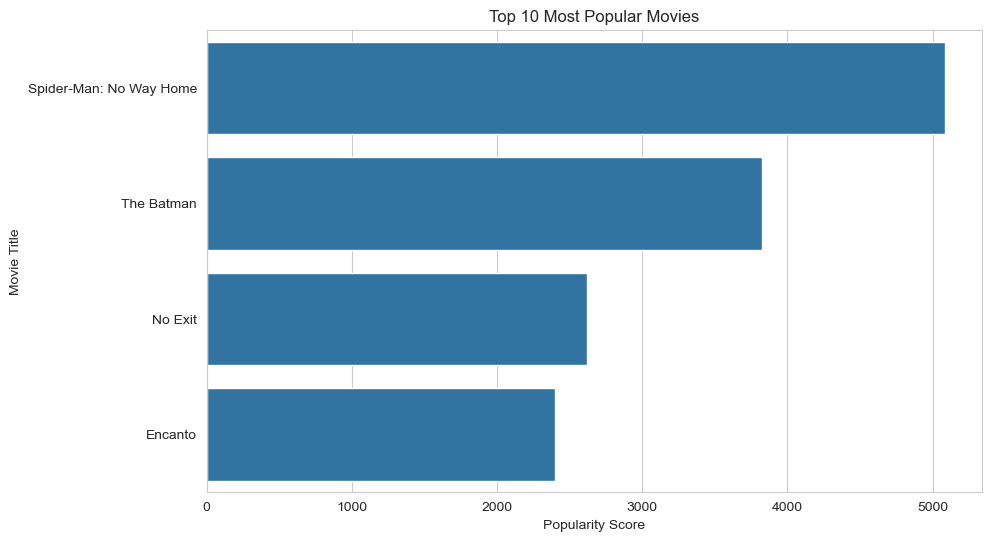

In [36]:
# Visualize the top 10 most popular movies

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_popular,
    x='Popularity',
    y='Title'
)

plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity Score')
plt.ylabel('Movie Title')

plt.show()

### Observation

- The chart displays the top 10 movies with the highest popularity scores.
- **Spider-Man: No Way Home** is the most popular movie in the dataset.
- The popularity scores of the top movies are significantly higher than the rest, indicating strong audience interest.

##  Q7. What are the Top 10 Highest Rated Movies?

In [37]:
# Get the top 10 highest rated movies

top_10_rated = (
    df[['Title', 'Vote_Average']]
    .drop_duplicates()
    .sort_values(by='Vote_Average', ascending=False)
    .head(10)
)

top_10_rated

,Title,Vote_Average
0,Spider-Man: No Way Home,popular
11373,Pushpa: The Rise - Part 1,popular
11108,Vertigo,popular
11112,The Diamond Arm,popular
11115,The Thin Red Line,popular
11132,Unbroken,popular
11137,Plan B,popular
11170,Blow,popular
11175,Casablanca,popular
11177,The Deer Hunter,popular


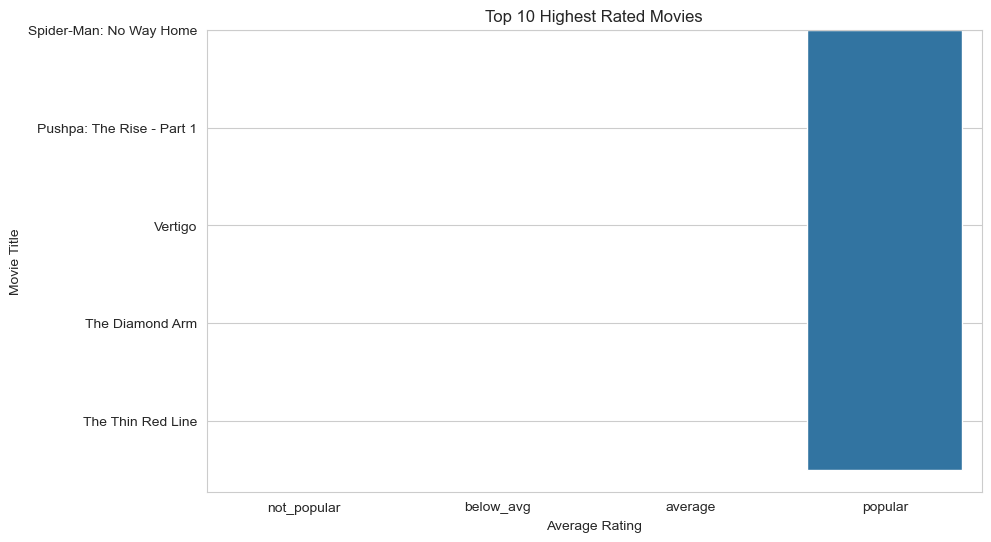

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_rated,
    x='Vote_Average',
    y='Title',
    errorbar = None
)

plt.title('Top 10 Highest Rated Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')

plt.show()

###  Observation

- The analysis identifies the **top 10 highest-rated movies** based on their average audience ratings.
- These movies have received exceptional ratings, indicating strong viewer satisfaction and positive reviews.
- High-rated movies represent some of the best-performing titles in terms of audience appreciation.
- This analysis helps identify critically acclaimed movies that stand out in the dataset.

##  Q8. Which Genres Have the Highest Average Popularity?

In [39]:
genre_popularity = (
    df.groupby('Genre', observed=True)['Popularity']
      .mean()
      .sort_values(ascending=False)
)

genre_popularity

Genre
Adventure          53.785530
Fantasy            52.986726
Animation          52.449432
Action             50.688837
Science Fiction    49.241125
Family             46.458322
Crime              44.625692
Thriller           43.024233
Mystery            40.325880
Horror             38.442648
Comedy             37.834018
Western            36.187912
War                35.321010
Music              33.863749
Romance            30.837862
Drama              30.110546
TV Movie           29.954715
Documentary        29.737700
History            28.429601
Name: Popularity, dtype: float64

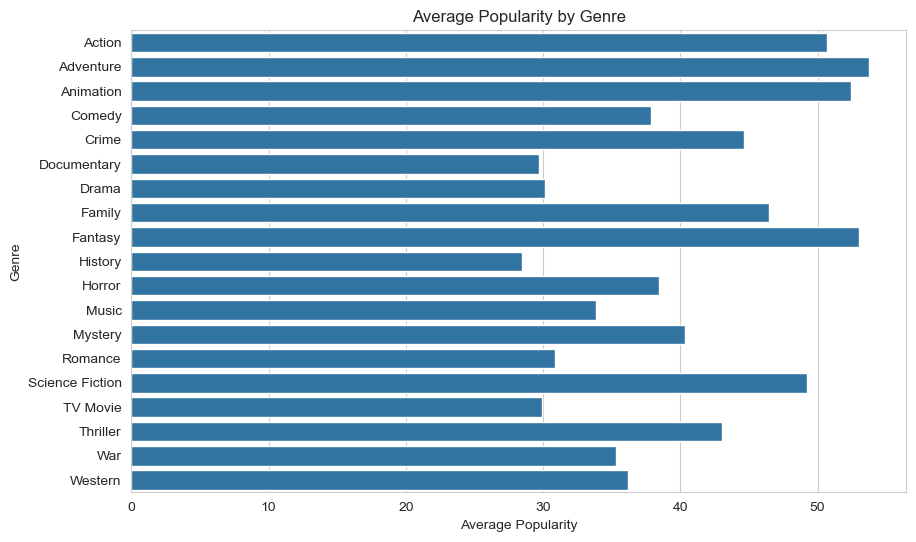

In [40]:
# Visualize the average popularity of each genre

plt.figure(figsize=(10,6))

sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index,
    errorbar=None
)

plt.title("Average Popularity by Genre")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

###  Observation

- The chart compares the average popularity score of each movie genre.
- Genres with higher average popularity generally attract larger audiences and receive more attention.
- This analysis helps identify which genres perform best in terms of audience interest.
- The top-ranked genre has the highest average popularity among all genres in the dataset.

## Q9. Which Genres Have Received the Highest Total Votes?

In [41]:
# Calculate the total vote count for each genre

genre_votes = (
    df.groupby('Genre', observed=True)['Vote_Count']
      .sum()
      .sort_values(ascending=False)
)

genre_votes

Genre
Drama              5141495
Action             4868675
Adventure          4313869
Comedy             3933497
Thriller           3631594
Science Fiction    2850476
Fantasy            2521940
Family             2046625
Crime              1980261
Romance            1803756
Animation          1525045
Horror             1448486
Mystery            1181275
History             527056
War                 448918
Music               297446
Western             186860
TV Movie             68441
Documentary          38224
Name: Vote_Count, dtype: int64

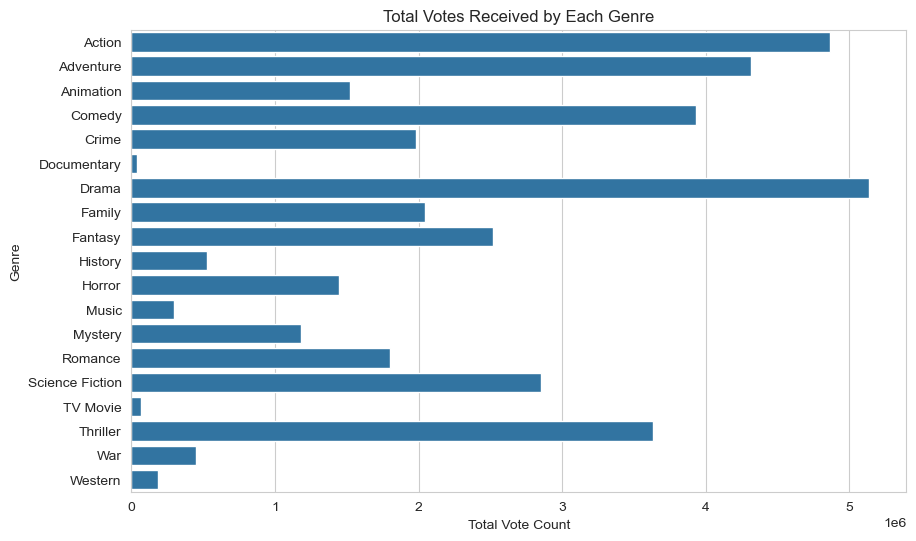

In [42]:
# Plot the graph
plt.figure(figsize=(10,6))

sns.barplot(
    x=genre_votes.values,
    y=genre_votes.index,
    errorbar=None
)

plt.title("Total Votes Received by Each Genre")
plt.xlabel("Total Vote Count")
plt.ylabel("Genre")

plt.show()

###  Observation

- The chart shows the total number of audience votes received by each movie genre.
- Genres with the highest vote counts have attracted the greatest audience engagement.
- This analysis highlights the genres that are most widely watched and reviewed by viewers.
- The top-ranked genre has received the highest cumulative number of votes in the dataset.

##  Q10. How Many Movies Were Released Each Year?

In [43]:
# Count the number of movies released each year

movies_per_year = df['Release_Date'].value_counts().sort_index()

movies_per_year

Release_Date
1902       3
1920       4
1921       5
1922       5
1925       2
        ... 
2018    1384
2019    1271
2020    1121
2021    1636
2022     275
Name: count, Length: 100, dtype: int64

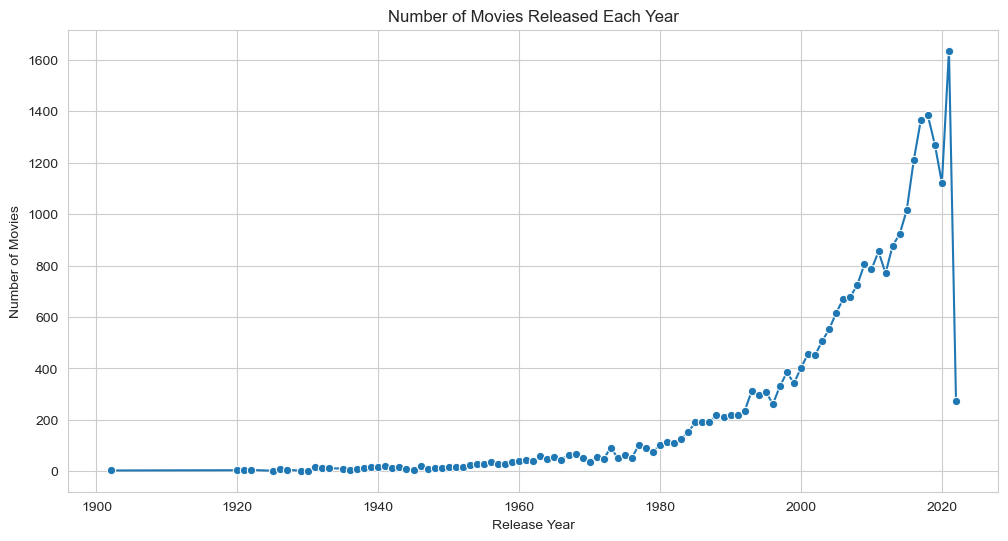

In [44]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=movies_per_year.index,
    y=movies_per_year.values,
    marker='o'
)

plt.title('Number of Movies Released Each Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')

plt.show()

###  Observation

- The line chart shows the yearly trend of movie releases in the dataset.
- The number of movies released has generally increased over time.
- Recent years contain a higher number of movie releases compared to earlier decades.
- This trend indicates significant growth in movie production over the years.

##  Q11. What is the Relationship Between Popularity and Vote Count?

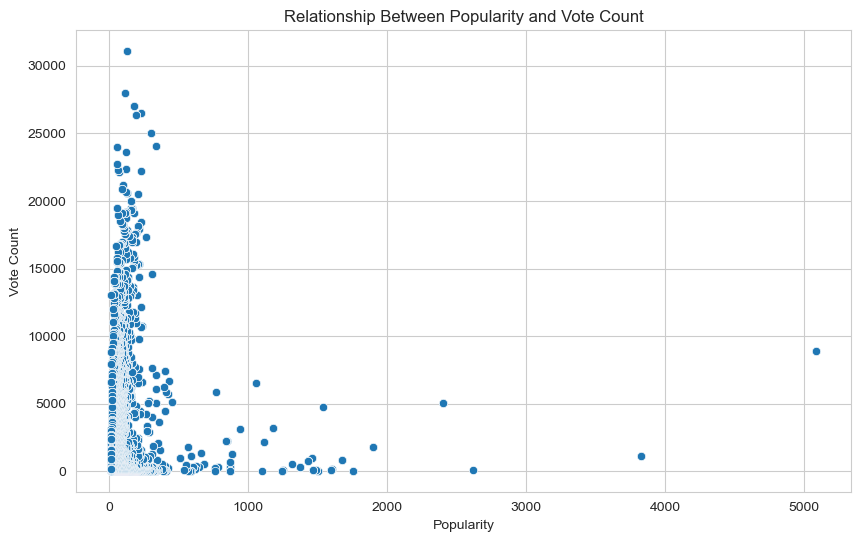

In [47]:
# Analyze the relationship between popularity and vote count

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Popularity',
    y='Vote_Count'
)

plt.title('Relationship Between Popularity and Vote Count')
plt.xlabel('Popularity')
plt.ylabel('Vote Count')

plt.show()

###  Observation

- The scatter plot shows a positive relationship between movie popularity and vote count.
- Movies with higher popularity generally receive more audience votes.
- Most movies are concentrated in the lower popularity and lower vote count region.
- A few blockbuster movies stand out with exceptionally high popularity and vote counts.

##  Q12. What is the Relationship Between Popularity and Ratings?

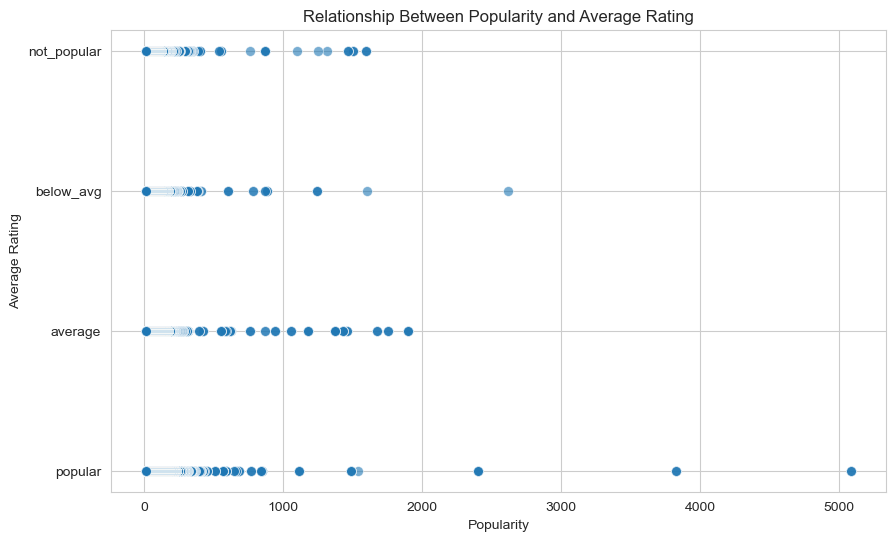

In [48]:
# Analyze the relationship between popularity and average rating

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Popularity',
    y='Vote_Average',
    alpha=0.6,
    s=50
)

plt.title('Relationship Between Popularity and Average Rating')
plt.xlabel('Popularity')
plt.ylabel('Average Rating')

plt.show()

###  Observation

- The scatter plot compares movie popularity with average audience ratings.
- While some highly popular movies also have high ratings, popularity does not always guarantee a higher rating.
- Most movies are concentrated in the medium rating range.
- This suggests that audience interest and audience satisfaction are related but not perfectly correlated.

##  Q13. What are the Top 5 Movies in Each Genre Based on Popularity?

In [49]:
# Find the top 5 most popular movies in each genre

top5_genre = (
    df.sort_values(by='Popularity', ascending=False)
      .groupby('Genre', observed=True)
      .head(5)
)

top5_genre[['Genre', 'Title', 'Popularity']]

,Genre,Title,Popularity
0,Action,Spider-Man: No Way Home,5083.954
2,Science Fiction,Spider-Man: No Way Home,5083.954
1,Adventure,Spider-Man: No Way Home,5083.954
3,Crime,The Batman,3827.658
5,Thriller,The Batman,3827.658
...,...,...,...
661,Documentary,Jackass Forever,169.376
697,TV Movie,Descendants: The Royal Wedding,165.257
771,Documentary,11M,157.390
817,TV Movie,Hilda and the Mountain King,151.978


###  Observation

- The analysis identifies the **top 5 most popular movies** within each genre.
- Ranking movies genre-wise makes it easier to compare the best-performing titles in every category.
- Several movies appear in multiple genres because they belong to more than one genre.
- This analysis helps discover the leading movies for each genre based on their popularity scores.

##  Q14. Which Decade Produced the Most Movies?

In [50]:
# Create a new column for decade

df['Decade'] = (df['Release_Date'] // 10) * 10

# Count movies released in each decade
decade_count = (
    df['Decade']
    .value_counts()
    .sort_index()
)

decade_count

Decade
1900        3
1920       32
1930       90
1940      131
1950      261
1960      512
1970      663
1980     1605
1990     2904
2000     5866
2010    10453
2020     3032
Name: count, dtype: int64

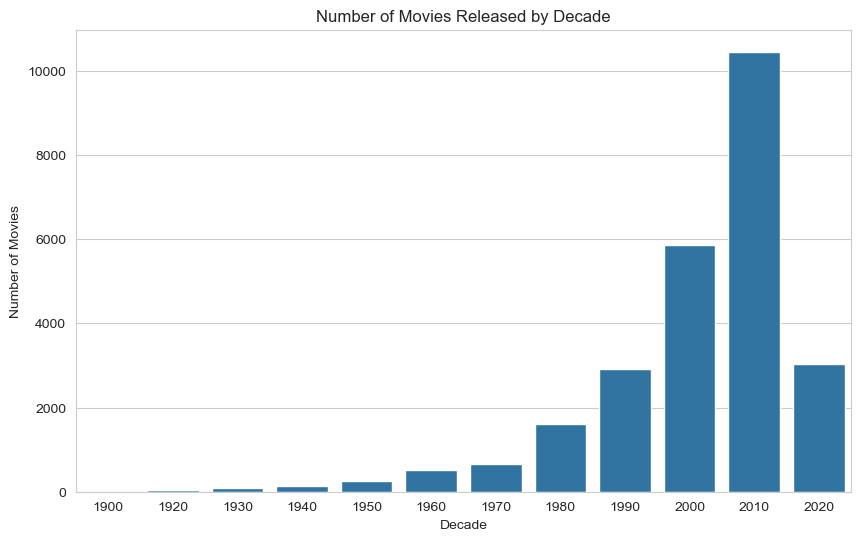

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=decade_count.index.astype(str),
    y=decade_count.values,
    errorbar=None
)

plt.title('Number of Movies Released by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')

plt.show()


###  Observation

- The chart shows the number of movies released in each decade.
- Movie production has increased steadily over time, with recent decades contributing the largest number of movies.
- Earlier decades contain relatively fewer movies compared to modern decades.
- This trend reflects the continuous growth of the global film industry.

#  Key Insights

- **Drama** emerged as the most frequent genre in the dataset, indicating its strong presence in the movie industry.
- **Spider-Man: No Way Home** was identified as the most popular movie, achieving the highest popularity score among all titles.
- Movie releases have increased significantly over the years, with the highest concentration of films produced in the most recent decade.
- Audience engagement is positively associated with movie popularity, as highly popular movies generally received a greater number of votes.
- Some genres consistently attracted higher popularity and audience attention, highlighting differences in viewer preferences across genres.
- The analysis of top-rated and most popular movies showed that commercial success and audience ratings do not always perfectly align, emphasizing the importance of evaluating multiple performance metrics.
- Visualizations helped uncover trends in movie production, genre distribution, popularity, ratings, and audience voting behavior, enabling better understanding of the dataset.
- Overall, exploratory data analysis (EDA) transformed raw movie data into meaningful insights that can support data-driven decision-making in the entertainment industry.

#  Conclusion

This project analyzed a Netflix movie dataset using Python, Pandas, Matplotlib, and Seaborn to uncover meaningful insights about movie genres, popularity, ratings, vote counts, and release trends.

Through data cleaning, preprocessing, and exploratory data analysis (EDA), several business questions were answered using visualizations and statistical analysis. The findings revealed genre popularity, audience engagement patterns, top-performing movies, and changes in movie production over time.

Overall, this project demonstrates practical skills in data cleaning, data visualization, exploratory data analysis, and extracting business insights from real-world datasets using Python.